In [14]:
# step 1 # load and explore the dataset
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import networkx as nx

In [15]:

file_path = "../data/train.txt"

triples = []

with open(file_path, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:  # skip empty lines
            head, relation, tail = line.split()
            triples.append((head, relation, tail))
print(f"Total triples loaded: {len(triples)}")

Total triples loaded: 13821


In [16]:
df = pd.DataFrame(triples, columns=["head", "relation", "tail"])
df.head()

,head,relation,tail
0,olivia0,sisterOf,selina10
1,olivia0,sisterOf,isabella11
2,olivia0,sisterOf,oskar24
3,olivia0,sisterOf,adam9
4,olivia0,secondAuntOf,lena18


In [17]:
entities = pd.unique(df[["head", "tail"]].values.ravel())

len(entities)


1316

In [18]:

relations = pd.unique(df["relation"].values.ravel())
len(relations)

28

In [19]:
unique_nodes = pd.unique(df[["head", "tail"]].values.ravel())
unique_nodes = unique_nodes.tolist()
len(unique_nodes), unique_nodes[:10]
# print(f"Total unique entities: {len(unique_nodes)}")

(1316,
 ['olivia0',
  'selina10',
  'isabella11',
  'oskar24',
  'adam9',
  'lena18',
  'fabian26',
  'leon16',
  'johanna22',
  'jonas23'])

In [20]:
# Count occurrences of each relation
relation_counts = df["relation"].value_counts()

# Convert to dictionary
relation_count_dict = relation_counts.to_dict()

# Inspect
relation_count_dict


{'grandsonOf': 814,
 'grandmotherOf': 813,
 'grandfatherOf': 813,
 'granddaughterOf': 812,
 'motherOf': 733,
 'fatherOf': 733,
 'sisterOf': 636,
 'daughterOf': 628,
 'greatGrandsonOf': 624,
 'greatGrandmotherOf': 617,
 'greatGrandfatherOf': 617,
 'greatGranddaughterOf': 610,
 'sonOf': 600,
 'brotherOf': 570,
 'auntOf': 556,
 'nephewOf': 514,
 'nieceOf': 496,
 'uncleOf': 454,
 'girlCousinOf': 445,
 'boyCousinOf': 391,
 'greatAuntOf': 312,
 'greatUncleOf': 237,
 'boyFirstCousinOnceRemovedOf': 180,
 'secondAuntOf': 175,
 'secondUncleOf': 158,
 'girlFirstCousinOnceRemovedOf': 153,
 'boySecondCousinOf': 68,
 'girlSecondCousinOf': 62}

In [21]:
relation_stats_df = relation_counts.reset_index()
relation_stats_df.columns = ["relation", "count"]

relation_stats_df


,relation,count
0,grandsonOf,814
1,grandmotherOf,813
2,grandfatherOf,813
3,granddaughterOf,812
4,motherOf,733
5,fatherOf,733
6,sisterOf,636
7,daughterOf,628
8,greatGrandsonOf,624
9,greatGrandmotherOf,617


In [22]:
print("Total triples:", len(df))
print("Unique nodes:", len(unique_nodes))
print("Unique relations:", len(relation_count_dict))


Total triples: 13821
Unique nodes: 1316
Unique relations: 28


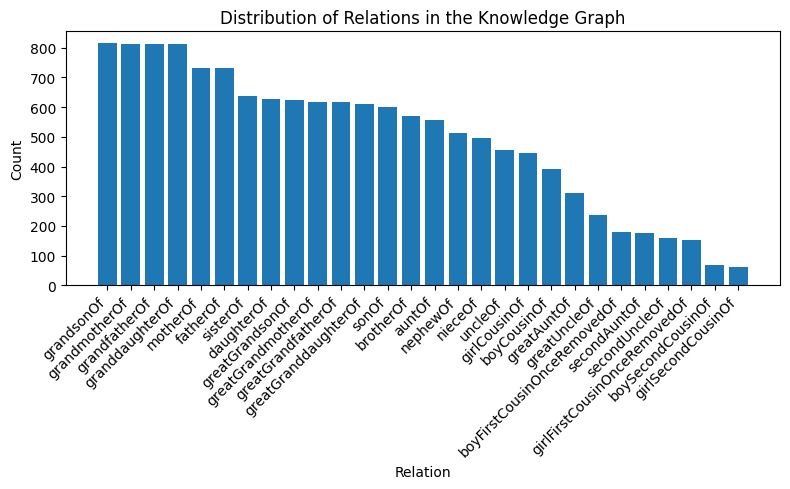

In [23]:
plt.figure(figsize=(8, 5))

plt.bar(
    relation_stats_df["relation"],
    relation_stats_df["count"]
)

plt.xlabel("Relation")
plt.ylabel("Count")
plt.title("Distribution of Relations in the Knowledge Graph")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()


In [24]:
G = nx.MultiDiGraph()
for _, row in df.iterrows():
    G.add_edge(
        row["head"],
        row["tail"],
        relation=row["relation"]
    )
print(f"Graph has {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")


Graph has 1316 nodes and 13821 edges.


In [25]:
list(G.edges(data=True))[:5]


[('olivia0', 'selina10', {'relation': 'sisterOf'}),
 ('olivia0', 'isabella11', {'relation': 'sisterOf'}),
 ('olivia0', 'oskar24', {'relation': 'sisterOf'}),
 ('olivia0', 'adam9', {'relation': 'sisterOf'}),
 ('olivia0', 'lena18', {'relation': 'secondAuntOf'})]